In [7]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

In [8]:
df = pd.read_csv("data/titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Abalizar el DataFrame

In [9]:
df.shape

(891, 12)

Para trabajar con los datos, necesitamos informacion.

In [10]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


Como limpieza de datos, vamos a poner valores por defecto a Age:0,
Cabin: CNada, Embarked: "J"

In [11]:
df = df.fillna({"Age": 0, "Cabin": "Cnada", "Embarked": "J"})
df.count()

PassengerId    891
Survived       891
Pclass         891
Name           891
Sex            891
Age            891
SibSp          891
Parch          891
Ticket         891
Fare           891
Cabin          891
Embarked       891
dtype: int64

Podemos hacer segregacionpor Genero/Sex

In [12]:
df_generos = df.groupby("Sex")
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,23.799293,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,17.596074,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,6.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,24.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Vamos a Utilizar codigo para extraer datos.
Quiero los pasajeros totales.
Supervivientes = 1
Fallecidos = 0

In [17]:
pasajeros = df.shape[0]
supervivientes = df[ df.Survived == 1 ]
num_survived = supervivientes.shape[0]
fallecidos = df.query("Survived == 0")
num_fallecidos = fallecidos.shape[0]
print(f"Pasajeros Totales: {pasajeros}")
print(f"Supervivientes: {num_survived}")
print(f"Fallecidos: {num_fallecidos}")



Pasajeros Totales: 891
Supervivientes: 342
Fallecidos: 549


Vamos a crear un grafico PIE con estos datos.
Para ello, debemos llevar estas variables a un diccionario.

In [18]:
data = {
    "Datos": ["Pasajeros Totales", "Supervivientes", "Fallecidos"],
    "Valores": [pasajeros, num_survived, num_fallecidos],
}

df_datos = pd.DataFrame.from_dict(data)
df_datos

,Datos,Valores
0,Pasajeros Totales,891
1,Supervivientes,342
2,Fallecidos,549


<Axes: >

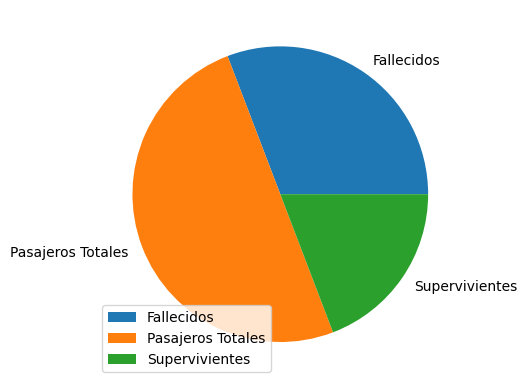

In [20]:
df_datos.groupby("Datos").sum().plot(kind="pie", y="Valores")
